#### Importing the dataset

In [45]:
import pandas as pd

data = pd.read_csv("dataset.csv")

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns)

Dataset shape: (6607, 20)

Columns:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')


#### Select the required features

In [46]:
selected_columns = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity",
    "Extracurricular_Activities",
    "Exam_Score"
]

data_clean = data[selected_columns]

data_clean.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Extracurricular_Activities,Exam_Score
0,23,84,7,73,0,3,No,67
1,19,64,8,59,2,4,No,61
2,24,98,7,91,2,4,Yes,74
3,29,89,8,98,1,4,Yes,71
4,19,92,6,65,3,4,Yes,70


#### Convert Yes/No to 1/0

In [47]:
data_clean["Extracurricular_Activities"] = data_clean["Extracurricular_Activities"].map({
    "Yes":1,
    "No":0
})

#### Split Features and Target

In [48]:
X = data_clean.drop("Exam_Score", axis=1)
y = data_clean["Exam_Score"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (6607, 7)
Output shape: (6607,)


#### Describe the data

In [49]:
X.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Extracurricular_Activities
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,0.596035
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,0.490728
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,0.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,1.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,1.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,1.000000


#### Feature Scaling

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Checking shape

In [51]:
X_scaled.shape

(6607, 7)

#### Train/Test Split

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (5285, 7)
Testing samples: (1322, 7)


#### Imports for the ANN

In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

#### Model definition

In [54]:
model = Sequential([
    Input(shape=(7,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])

In [55]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

#### Training

In [56]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [57]:
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4235.4272 - mae: 64.9163 - val_loss: 3769.5945 - val_mae: 61.1680
Epoch 2/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2985.8945 - mae: 53.9803 - val_loss: 1990.3898 - val_mae: 43.6728
Epoch 3/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1115.6334 - mae: 30.8134 - val_loss: 421.1146 - val_mae: 17.7661
Epoch 4/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 217.8274 - mae: 12.1379 - val_loss: 129.1467 - val_mae: 9.1555
Epoch 5/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 110.9180 - mae: 8.3781 - val_loss: 102.6219 - val_mae: 8.0176
Epoch 6/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 92.6369 - mae: 7.6026 - val_loss: 89.2633 - val_mae: 7.4464
Epoch 7/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 80.5760 - mae: 7.0873 - val_loss: 78.4279 - val_mae: 6.9684
Epoch 8/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 70.8123 - mae: 6.6407 - val_loss: 69.6641 - val_mae: 6.5494
Epoch 9/25
133/133

#### Evaluation on test data

In [58]:
loss, mae = model.evaluate(X_test, y_test)

print("Test MAE:", mae)

 1/42 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 26.6205 - mae: 2.6665

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10.1840 - mae: 2.2600 
Test MAE: 2.259995460510254


#### Sample prediction

In [59]:
sample = X_test[0].reshape(1, -1)

pred = model.predict(sample)

print("Predicted:", pred[0][0])
print("Actual:", y_test.iloc[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted: 65.022026
Actual: 65


#### Training curve visualization

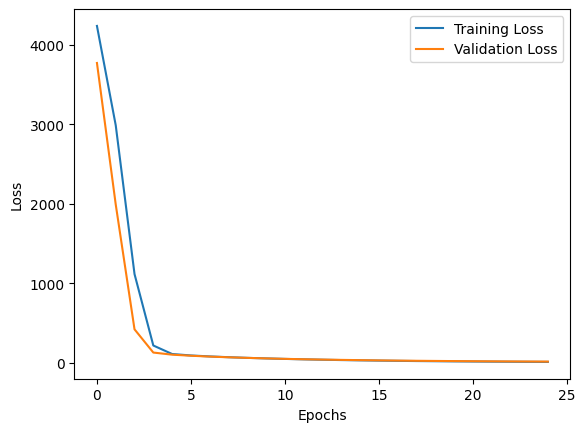

In [60]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

#### Grade categories

In [70]:
data_clean["Grade"] = pd.qcut(
    data_clean["Exam_Score"],
    q=4,
    labels=[0,1,2,3]
).astype(int)

In [71]:
data_clean["Grade"].value_counts()

Grade
0    2131
3    1625
1    1468
2    1383
Name: count, dtype: int64

#### Classification inputs

In [72]:
X_class = data_clean.drop(["Exam_Score","Grade"], axis=1)
y_class = data_clean["Grade"]

#### Scaling

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_class_scaled = scaler.fit_transform(X_class)

#### Train test split

In [74]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_scaled,
    y_class,
    test_size=0.2,
    random_state=42
)

#### ANN Classifier

In [75]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_class = Sequential([
    Input(shape=(7,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(4, activation='softmax')
])

#### Compiling the model

In [76]:
model_class.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### ANN Training

In [77]:
history_class = model_class.fit(
    X_train_c,
    y_train_c,
    epochs=25,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2817 - loss: 1.3711 - val_accuracy: 0.4002 - val_loss: 1.2595
Epoch 2/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5315 - loss: 1.1145 - val_accuracy: 0.5516 - val_loss: 1.0173
Epoch 3/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5970 - loss: 0.9027 - val_accuracy: 0.5866 - val_loss: 0.8919
Epoch 4/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6400 - loss: 0.8197 - val_accuracy: 0.6339 - val_loss: 0.8493
Epoch 5/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6516 - loss: 0.7904 - val_accuracy: 0.6310 - val_loss: 0.8280
Epoch 6/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6582 - loss: 0.7780 - val_accuracy: 0.6377 - val_loss: 0.8210
Epoch 7/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6623 - loss: 0.7716 - val_accuracy: 0.6462 - val_loss: 0.8193
Epoch 8/25
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6596 - loss: 0.7667 - val_accuracy: 0.

#### Evaluating on test data

In [78]:
loss, accuracy = model_class.evaluate(X_test_c, y_test_c)

print("Test Accuracy:", accuracy)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6604 - loss: 0.7499
Test Accuracy: 0.6603630781173706


#### Confusion Matrix

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


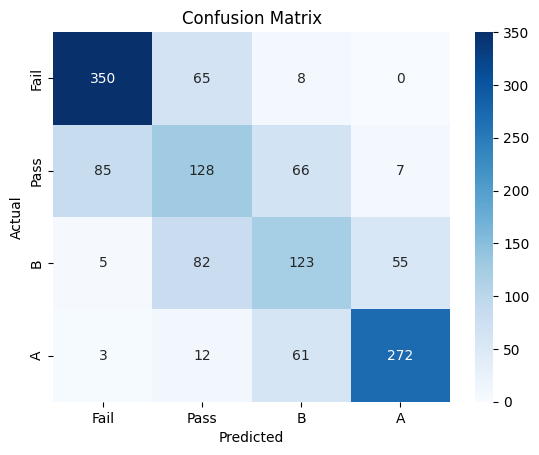

In [79]:
y_pred = model_class.predict(X_test_c)
y_pred_classes = y_pred.argmax(axis=1)

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_c, y_pred_classes)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Fail","Pass","B","A"],
            yticklabels=["Fail","Pass","B","A"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### Accuracy curves

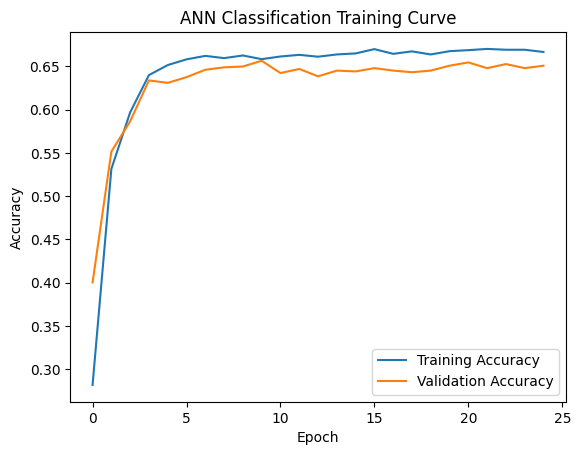

In [80]:
plt.plot(history_class.history['accuracy'], label='Training Accuracy')
plt.plot(history_class.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.title("ANN Classification Training Curve")

plt.show()

#### Grade distribution

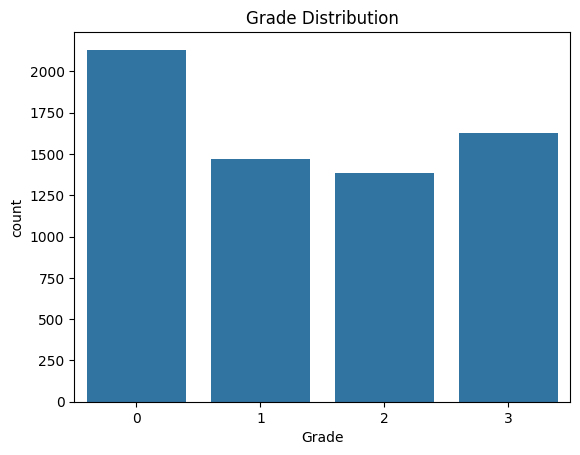

In [81]:
sns.countplot(x=data_clean["Grade"])

plt.title("Grade Distribution")
plt.show()

In [82]:
model.save("regression_model.h5")
model_class.save("classifier_model.h5")

In [83]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']